In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import warnings, time, os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
os.makedirs('/kaggle/working/figures', exist_ok=True)
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

2026-04-28 01:02:23.683477: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777338143.973639      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777338144.073142      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777338144.784422      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777338144.784529      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777338144.784536      55 computation_placer.cc:177] computation placer alr

GPU: []


2026-04-28 01:02:58.005370: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
# Prints every file
for root, dirs, files in os.walk('/kaggle/input/'):
    for f in files:
        fp = os.path.join(root, f)
        print(f"{fp}  ({os.path.getsize(fp)/1e9:.2f} GB)")

/kaggle/input/datasets/bishals098/nasa-cmapss-2-engine-degradation/N-CMAPSS_DS08a-009.h5  (3.24 GB)
/kaggle/input/datasets/bishals098/nasa-cmapss-2-engine-degradation/N-CMAPSS_DS08c-008.h5  (2.41 GB)
/kaggle/input/datasets/bishals098/nasa-cmapss-2-engine-degradation/N-CMAPSS_DS05.h5  (2.60 GB)
/kaggle/input/datasets/bishals098/nasa-cmapss-2-engine-degradation/N-CMAPSS_DS08d-010.h5  (2.89 GB)
/kaggle/input/datasets/bishals098/nasa-cmapss-2-engine-degradation/Run_to_Failure_Simulation_Under_Real_Flight_Conditions_Dataset.pdf  (0.00 GB)
/kaggle/input/datasets/bishals098/nasa-cmapss-2-engine-degradation/N-CMAPSS_DS03-012.h5  (3.69 GB)
/kaggle/input/datasets/bishals098/nasa-cmapss-2-engine-degradation/N-CMAPSS_DS01-005.h5  (2.87 GB)
/kaggle/input/datasets/bishals098/nasa-cmapss-2-engine-degradation/N-CMAPSS_Example_data_loading_and_exploration.ipynb  (0.00 GB)
/kaggle/input/datasets/bishals098/nasa-cmapss-2-engine-degradation/N-CMAPSS_DS04.h5  (3.75 GB)
/kaggle/input/datasets/bishals098/nas

In [3]:
# Setting the file path to the N-CMAPSS HDF5 file

H5_PATH = '/kaggle/input/datasets/bishals098/nasa-cmapss-2-engine-degradation/N-CMAPSS_DS02-006.h5' 

# Open file and print keys
with h5py.File(H5_PATH, 'r') as f:
    print("Keys in file:")
    for key in f.keys():
        shape = f[key].shape if hasattr(f[key], 'shape') else 'group'
        print(f"  {key}: {shape}")

Keys in file:
  A_dev: (5263447, 4)
  A_test: (1253743, 4)
  A_var: (4,)
  T_dev: (5263447, 10)
  T_test: (1253743, 10)
  T_var: (10,)
  W_dev: (5263447, 4)
  W_test: (1253743, 4)
  W_var: (4,)
  X_s_dev: (5263447, 14)
  X_s_test: (1253743, 14)
  X_s_var: (14,)
  X_v_dev: (5263447, 14)
  X_v_test: (1253743, 14)
  X_v_var: (14,)
  Y_dev: (5263447, 1)
  Y_test: (1253743, 1)


In [4]:
# N-CMAPSS stores data with _dev (training) and _test (testing) suffixes
# Variable groups: 
# W = operating conditions (4 features)
# X_s = physical sensors (14 features)
# X_v = virtual sensors (18 features)
# T = health parameters,
# Y = RUL labels
# A = auxiliary info

with h5py.File(H5_PATH, 'r') as f:
    
    # Training data
    W_dev  = np.array(f['W_dev'])             # Operating conditions (4 vars: alt, Mach, TRA, T2)
    X_s_dev = np.array(f['X_s_dev'])          # Physical sensors (14 features)
    X_v_dev = np.array(f['X_v_dev'])          # Virtual sensors (18 features)
    Y_dev  = np.array(f['Y_dev'])             # RUL labels
    A_dev  = np.array(f['A_dev'])             # Auxilla
    
    # Test data
    W_test  = np.array(f['W_test'])
    X_s_test = np.array(f['X_s_test'])
    X_v_test = np.array(f['X_v_test'])
    Y_test  = np.array(f['Y_test'])
    A_test  = np.array(f['A_test'])

print(f"W_dev:   {W_dev.shape}  (operating conditions)")
print(f"X_s_dev: {X_s_dev.shape}  (physical sensors)")
print(f"X_v_dev: {X_v_dev.shape}  (virtual sensors)")
print(f"Y_dev:   {Y_dev.shape}  (RUL)")
print(f"A_dev:   {A_dev.shape}  (unit/cycle info)")

# Combining operating conditions and physical sensors into one feature matrix
# (skipped virtual sensors to keep things simpler and faster)
X_train_raw = np.concatenate([W_dev, X_s_dev], axis=1)
X_test_raw  = np.concatenate([W_test, X_s_test], axis=1)
y_train_raw = Y_dev.ravel()   
y_test_raw  = Y_test.ravel()

# Unit IDs for engine -level splitting
unit_train = A_dev[:, 0].astype(int)
unit_test  = A_test[:, 0].astype(int)

# Name every feature for plotting and SHAP analysis
op_names = ['alt', 'Mach', 'TRA', 'T2']
sensor_names = ['Wf', 'Nf', 'Nc', 'T24', 'T30', 'T48', 'T50',
                'P15', 'P21', 'P24', 'Ps30', 'P40', 'P50', 'farB']
feature_names = op_names + sensor_names

n_op = W_dev.shape[1]
n_sensor = X_s_dev.shape[1]
n_features = n_op + n_sensor   #18 total features

print(f"Operating: {n_op} cols, Sensors: {n_sensor} cols, Total: {n_features}")

W_dev:   (5263447, 4)  (operating conditions)
X_s_dev: (5263447, 14)  (physical sensors)
X_v_dev: (5263447, 14)  (virtual sensors)
Y_dev:   (5263447, 1)  (RUL)
A_dev:   (5263447, 4)  (unit/cycle info)
Operating: 4 cols, Sensors: 14 cols, Total: 18


In [5]:
# Normalise all 18 features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# Train/val split by Engine instead of timesteps preventing data leakage
train_engines = np.unique(unit_train)
np.random.seed(42)   #reproducible shuffle
np.random.shuffle(train_engines)
n_val = max(1, len(train_engines) // 5)  # 20% for validation
val_engines = set(train_engines[:n_val])

# Boolean mask for every sample belonging to a validation engine
val_mask = np.isin(unit_train, list(val_engines))
X_train = X_train_scaled[~val_mask]   # training samples
y_train = y_train_raw[~val_mask]      # training RUL labels
X_val   = X_train_scaled[val_mask]    # validation samples
y_val   = y_train_raw[val_mask]       # validation RUL labels

print(f"Train: {len(X_train):,} samples ({len(train_engines)-n_val} engines)")
print(f"Val:   {len(X_val):,} samples ({n_val} engines)")
print(f"Test:  {len(X_test_scaled):,} samples ({len(np.unique(unit_test))} engines)")
print(f"Val engines: {sorted(val_engines)}")

# Subsampling if dataset is too large
MAX_TRAIN = 1_000_000   #samples
if len(X_train) > MAX_TRAIN:
    print(f"\nSubsampling train: {len(X_train):,} → {MAX_TRAIN:,}")
    idx = np.random.choice(len(X_train), MAX_TRAIN, replace=False)
    X_train_sub = X_train[idx]
    y_train_sub = y_train[idx]
else:
    X_train_sub = X_train    # if under 1 million use everything
    y_train_sub = y_train

Train: 4,410,305 samples (5 engines)
Val:   853,142 samples (1 engines)
Test:  1,253,743 samples (3 engines)
Val engines: [np.int64(2)]

Subsampling train: 4,410,305 → 1,000,000


Top 10 features correlated with RUL:
T24    -0.126475
Nc     -0.074675
P50     0.024205
farB   -0.020594
Mach    0.015666
Wf     -0.011008
alt     0.010162
Nf      0.010153
Ps30   -0.008643
P15    -0.008304


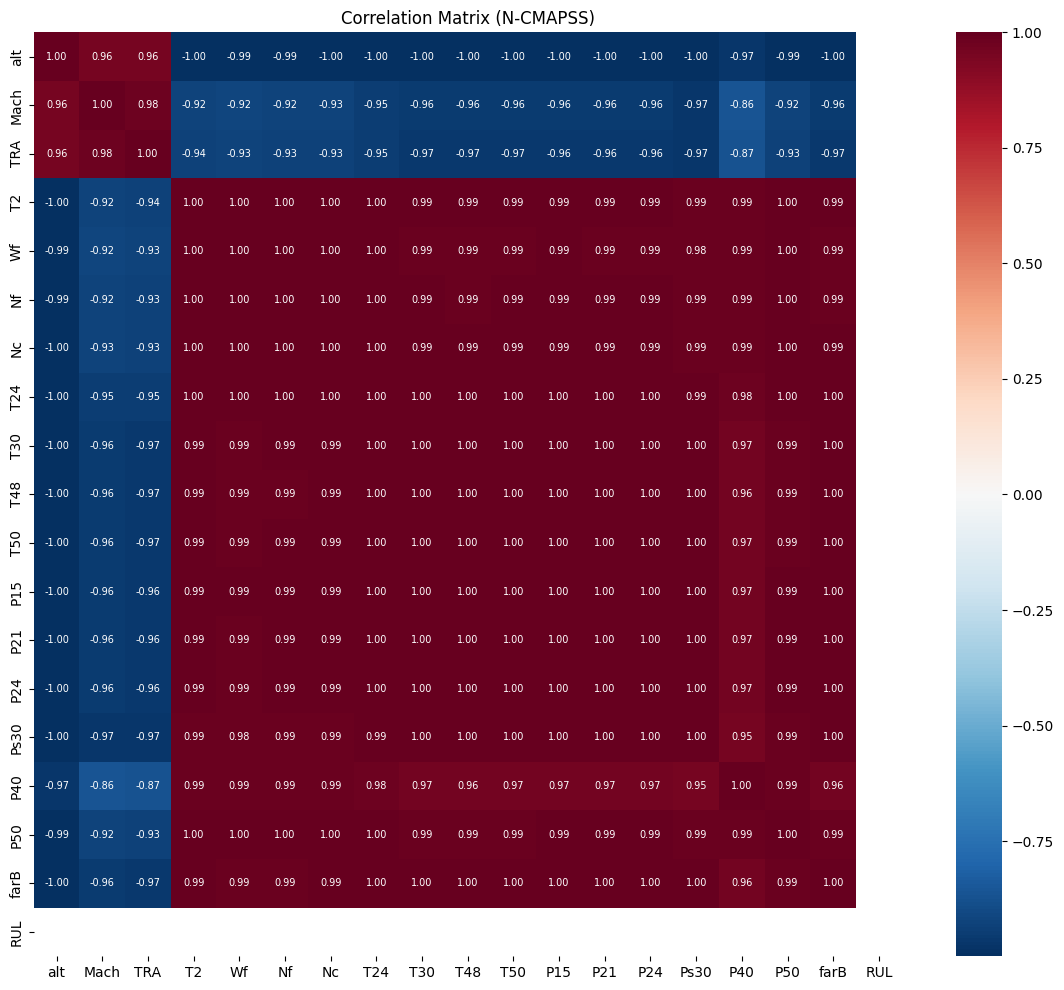

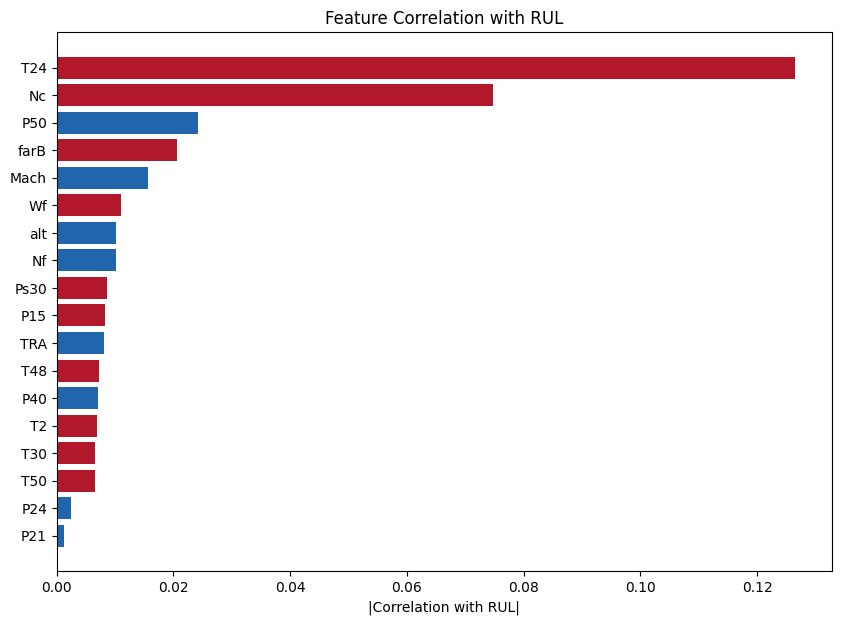


Mean |r| by category:
  Sensors (14):   0.0225
  Operating (4): 0.0102


In [6]:
## Exploratory Data Analysis

# Correlations between 18 features and RUL
corrs = {}
for i, name in enumerate(feature_names):
    corrs[name] = np.corrcoef(X_train_scaled[:, i], y_train_raw)[0, 1]
corrs = pd.Series(corrs).sort_values(key=abs, ascending=False)
print("Top 10 features correlated with RUL:")
print(corrs.head(10).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(14, 12))
corr_df = pd.DataFrame(X_train_scaled[:5000], columns=feature_names)  # subsample for speed
corr_df['RUL'] = y_train_raw[:5000]
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, annot_kws={'size':7})
ax.set_title('Correlation Matrix (N-CMAPSS)')
plt.savefig('/kaggle/working/figures/correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Correlation bar chart
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2166ac' if v > 0 else '#b2182b' for v in corrs.values]
ax.barh(range(len(corrs)), abs(corrs.values), color=colors)
ax.set_yticks(range(len(corrs))); ax.set_yticklabels(corrs.index)
ax.set_xlabel('|Correlation with RUL|'); ax.invert_yaxis()
ax.set_title('Feature Correlation with RUL')
plt.savefig('/kaggle/working/figures/feature_corr_bar.png', bbox_inches='tight')
plt.show()

# Sensor vs operating category
sensor_corrs = [abs(corrs[s]) for s in sensor_names if s in corrs]
op_corrs = [abs(corrs[s]) for s in op_names if s in corrs]
print(f"\nMean |r| by category:")
print(f"  Sensors ({len(sensor_names)}):   {np.mean(sensor_corrs):.4f}")
print(f"  Operating ({len(op_names)}): {np.mean(op_corrs):.4f}")

LR: RMSE=11.81, MAE=10.16, R²=0.6123, Time=1.10s


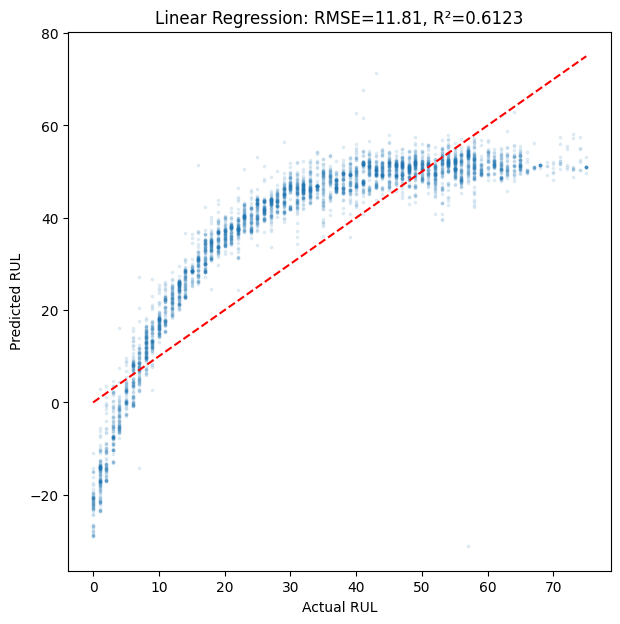

In [7]:
t0 = time.time()    # timer to measure training duration
lr_model = LinearRegression().fit(X_train_sub, y_train_sub)
# Training Linear regression on subsampled training data
lr_time = time.time() - t0

y_pred_lr = lr_model.predict(X_test_scaled)  # predicting RUL for every test sample
lr_rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred_lr))   # RMSE
lr_mae  = mean_absolute_error(y_test_raw, y_pred_lr)           # MAE
lr_r2   = r2_score(y_test_raw, y_pred_lr)                      # R squared
print(f"LR: RMSE={lr_rmse:.2f}, MAE={lr_mae:.2f}, R²={lr_r2:.4f}, Time={lr_time:.2f}s")

# Scatter plot
fig, ax = plt.subplots(figsize=(7, 7))
s = np.random.choice(len(y_test_raw), min(5000, len(y_test_raw)), replace=False)
# Random 5000 test points
ax.scatter(y_test_raw[s], y_pred_lr[s], alpha=0.1, s=3)
ax.plot([y_test_raw.min(), y_test_raw.max()], [y_test_raw.min(), y_test_raw.max()], 'r--')
ax.set_xlabel('Actual RUL'); ax.set_ylabel('Predicted RUL')
ax.set_title(f'Linear Regression: RMSE={lr_rmse:.2f}, R²={lr_r2:.4f}')
plt.savefig('/kaggle/working/figures/lr_scatter.png')
plt.show()

Grid search:
  depth=4, lr=0.05: RMSE=11.74
  depth=4, lr=0.1: RMSE=10.72
  depth=4, lr=0.2: RMSE=10.30
  depth=6, lr=0.05: RMSE=10.18
  depth=6, lr=0.1: RMSE=9.77
  depth=6, lr=0.2: RMSE=9.60
  depth=8, lr=0.05: RMSE=9.42
  depth=8, lr=0.1: RMSE=9.28
  depth=8, lr=0.2: RMSE=9.28
Best: depth=8, lr=0.1, RMSE=9.28
[0]	validation_0-rmse:21.50545	validation_1-rmse:20.69010
[50]	validation_0-rmse:10.09044	validation_1-rmse:10.89630
[100]	validation_0-rmse:8.53378	validation_1-rmse:9.73658
[150]	validation_0-rmse:7.90510	validation_1-rmse:9.40693
[200]	validation_0-rmse:7.50656	validation_1-rmse:9.23249
[250]	validation_0-rmse:7.23641	validation_1-rmse:9.11736
[299]	validation_0-rmse:7.04274	validation_1-rmse:9.05513

XGBoost: RMSE=9.28, MAE=7.22, R²=0.7606, Time=40.9s
vs LR: +21.4%

5-Fold CV:
  Fold 1: 13.41
  Fold 2: 10.09
  Fold 3: 7.09
  Fold 4: 8.99
  Fold 5: 10.24
  Mean: 9.96 ± 2.06


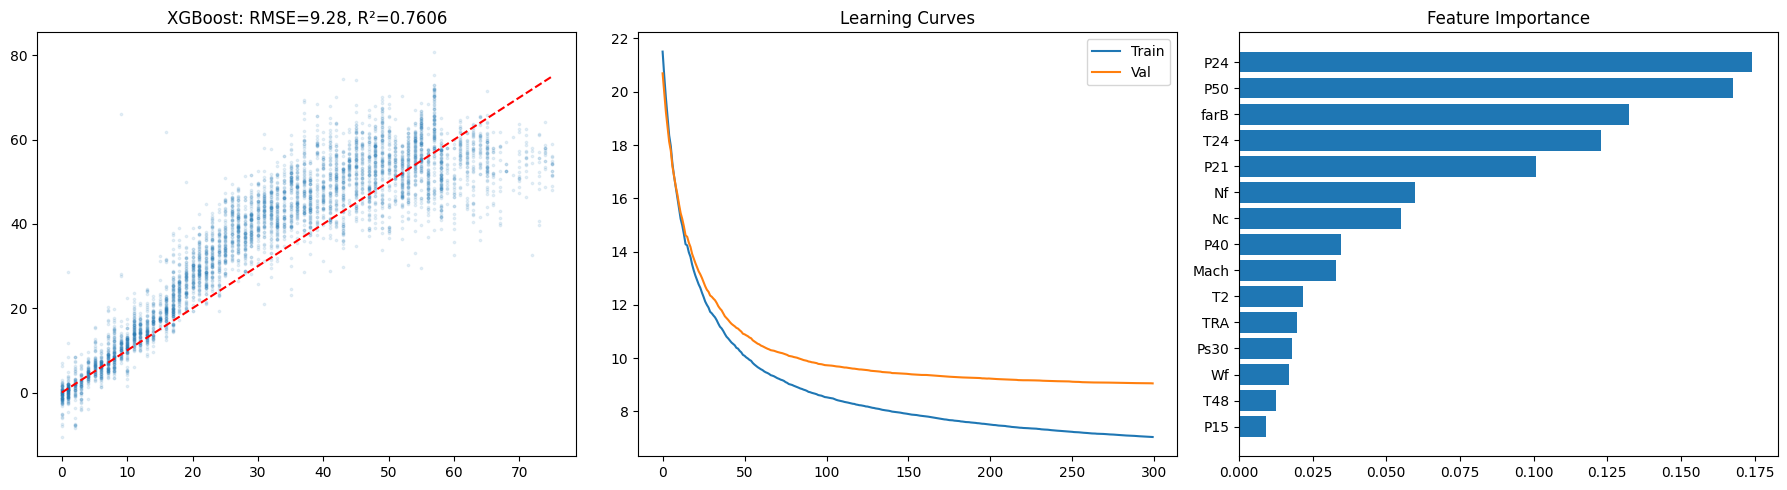

In [8]:
# Testing 9 combinations of hyper paramters to find the best XGBoost configuration
print("Grid search:")
results = []
for md in [4, 6, 8]:               # max depth
    for lr in [0.05, 0.1, 0.2]:    # learning rate
        m = xgb.XGBRegressor(
            n_estimators=300,     # 300 trees
            learning_rate=lr,     
            max_depth=md,
            subsample=0.8,        # 80% for training each tree
            colsample_bytree=0.8, 
            tree_method='hist',   # histogram based tree building
            device='cuda',        # run on GPU
            random_state=42,      # reproducibility
            early_stopping_rounds=20, 
            eval_metric='rmse')
        m.fit(X_train_sub, y_train_sub, 
              eval_set=[(X_val, y_val)], v
              erbose=0)
        pred = m.predict(X_test_scaled)    # predict on test set
        rmse = np.sqrt(mean_squared_error(y_test_raw, pred))     # calculate RMSE
        results.append({'depth': md, 'lr': lr, 'rmse': rmse, 'iters': m.best_iteration})
        print(f"  depth={md}, lr={lr}: RMSE={rmse:.2f}")

rdf = pd.DataFrame(results)
best = rdf.loc[rdf['rmse'].idxmin()]    # row with lowest RMSE
print(f"Best: depth={int(best['depth'])}, lr={best['lr']}, RMSE={best['rmse']:.2f}")
rdf.to_csv('/kaggle/working/figures/hyperparam_search.csv', index=False)

# Training final model with the best hyperparamters
t0 = time.time()
xgb_model = xgb.XGBRegressor(n_estimators=300, learning_rate=best['lr'],
    max_depth=int(best['depth']), subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', device='cuda', random_state=42, early_stopping_rounds=20, eval_metric='rmse')
xgb_model.fit(X_train_sub, y_train_sub,
              eval_set=[(X_train_sub, y_train_sub), (X_val, y_val)], verbose=50)
xgb_time = time.time() - t0

y_pred_xgb = xgb_model.predict(X_test_scaled)
xgb_rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred_xgb))
xgb_mae  = mean_absolute_error(y_test_raw, y_pred_xgb)
xgb_r2   = r2_score(y_test_raw, y_pred_xgb)
print(f"\nXGBoost: RMSE={xgb_rmse:.2f}, MAE={xgb_mae:.2f}, R²={xgb_r2:.4f}, Time={xgb_time:.1f}s")
print(f"vs LR: {(1-xgb_rmse/lr_rmse)*100:+.1f}%")

# 5-fold Cross Validation (engine-level grouping)
print("\n5-Fold CV:")
gkf = GroupKFold(n_splits=5)
cv = []
for fold, (tr, va) in enumerate(gkf.split(X_train_scaled, y_train_raw, unit_train)):
    m = xgb.XGBRegressor(n_estimators=300, learning_rate=best['lr'],
        max_depth=int(best['depth']), subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', device='cuda', random_state=42, early_stopping_rounds=20, eval_metric='rmse')
    m.fit(X_train_scaled[tr], y_train_raw[tr], eval_set=[(X_train_scaled[va], y_train_raw[va])], verbose=0)
    fold_rmse = np.sqrt(mean_squared_error(y_train_raw[va], m.predict(X_train_scaled[va])))
    cv.append(fold_rmse)
    print(f"  Fold {fold+1}: {fold_rmse:.2f}")
print(f"  Mean: {np.mean(cv):.2f} ± {np.std(cv):.2f}") # Mean + std tells us how consistent performance us across engine combinations

# Figures
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
s = np.random.choice(len(y_test_raw), min(5000, len(y_test_raw)), replace=False)
axes[0].scatter(y_test_raw[s], y_pred_xgb[s], alpha=0.1, s=3)
axes[0].plot([y_test_raw.min(),y_test_raw.max()],[y_test_raw.min(),y_test_raw.max()],'r--')
axes[0].set_title(f'XGBoost: RMSE={xgb_rmse:.2f}, R²={xgb_r2:.4f}')

ev = xgb_model.evals_result()
axes[1].plot(ev['validation_0']['rmse'], label='Train')
axes[1].plot(ev['validation_1']['rmse'], label='Val')
axes[1].legend(); axes[1].set_title('Learning Curves')

imp = xgb_model.feature_importances_
top = np.argsort(imp)[-15:]
axes[2].barh(range(len(top)), imp[top])
axes[2].set_yticks(range(len(top))); axes[2].set_yticklabels([feature_names[i] for i in top])
axes[2].set_title('Feature Importance')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/xgboost_results.png')
plt.show()

In [9]:
# Windowing for deep learning

WINDOW = 50  # 50 timesteps (standard for N-CMAPSS at 1Hz)

# N-CMAPSS large. Subsample to 0.1Hz (every 10th sample) to fit in memory
SUBSAMPLE = 10

def make_windows(X, y, units, window=WINDOW, subsample=SUBSAMPLE):
    Xw, yw = [], []                                 # holds windows and target RUL                    
    for uid in np.unique(units):                    # Process one engine at a time
        mask = units == uid                         
        feat = X[mask][::subsample]                 # subsampling
        rul = y[mask][::subsample]                    
        for i in range(len(feat) - window + 1):     # Window of each 50 timesteps across engine's data
            Xw.append(feat[i:i+window])
            yw.append(rul[i + window - 1])
    
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.float32)

print(f"Window={WINDOW}, Subsample=1/{SUBSAMPLE}")
print("Creating windows (this may take a minute)...")

# Create windows for each set seperately, maintaining the train/val/test seperation

X_tr_w, y_tr_w = make_windows(X_train_scaled[~val_mask], y_train_raw[~val_mask], unit_train[~val_mask])
#Training windows

X_va_w, y_va_w = make_windows(X_train_scaled[val_mask], y_train_raw[val_mask], unit_train[val_mask])
# validation windows

X_te_w, y_te_w = make_windows(X_test_scaled, y_test_raw, unit_test)
# Test windows

print(f"Train: {X_tr_w.shape} | Val: {X_va_w.shape} | Test: {X_te_w.shape}")
print(f"Memory: ~{(X_tr_w.nbytes + X_va_w.nbytes + X_te_w.nbytes) / 1e9:.2f} GB")

# If still too big, subsample training windows
MAX_WIN = 300_000
if len(X_tr_w) > MAX_WIN:
    print(f"Subsampling windows: {len(X_tr_w):,} → {MAX_WIN:,}")
    idx = np.random.choice(len(X_tr_w), MAX_WIN, replace=False)
    X_tr_w, y_tr_w = X_tr_w[idx], y_tr_w[idx]

Window=50, Subsample=1/10
Creating windows (this may take a minute)...
Train: (440787, 50, 18) | Val: (85266, 50, 18) | Test: (125228, 50, 18)
Memory: ~2.34 GB
Subsampling windows: 440,787 → 300,000


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 64)         │         5,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 12, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,465 (244.00 KB)

 Trainable params: 61,953 (242.00 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 84s 68ms/step - loss: 348.1492 - mae: 11.9309 - val_loss: 41.6065 - val_mae: 4.1716 - learning_rate: 0.0010
Epoch 2/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 83s 71ms/step - loss: 82.1517 - mae: 6.4069 - val_loss: 63.9962 - val_mae: 5.1873 - learning_rate: 0.0010
Epoch 3/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 81s 69ms/step - loss: 70.1088 - mae: 5.8867 - val_loss: 44.8643 - val_mae: 4.4139 - learning_rate: 0.0010
Epoch 4/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 83s 71ms/step - loss: 62.5243 - mae: 5.5487 - val_loss: 49.3024 - val_mae: 4.6540 - learning_rate: 0.0010
Epoch 5/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 85s 73ms/step - loss: 57.3512 - mae: 5.2994 - val_loss: 46.2237 - val_mae: 4.7717 - learning_rate: 0.0010
Epoch 6/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 91s 78ms/step - loss: 54.2935 - mae: 5.1560 - val_loss: 43.0679 - val_mae: 4.5247 - learning_rate: 0.0010
Epoch 7/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 92s 79ms/step - loss: 47.8104 - mae: 4.8176 - val_loss: 36.3730 - va

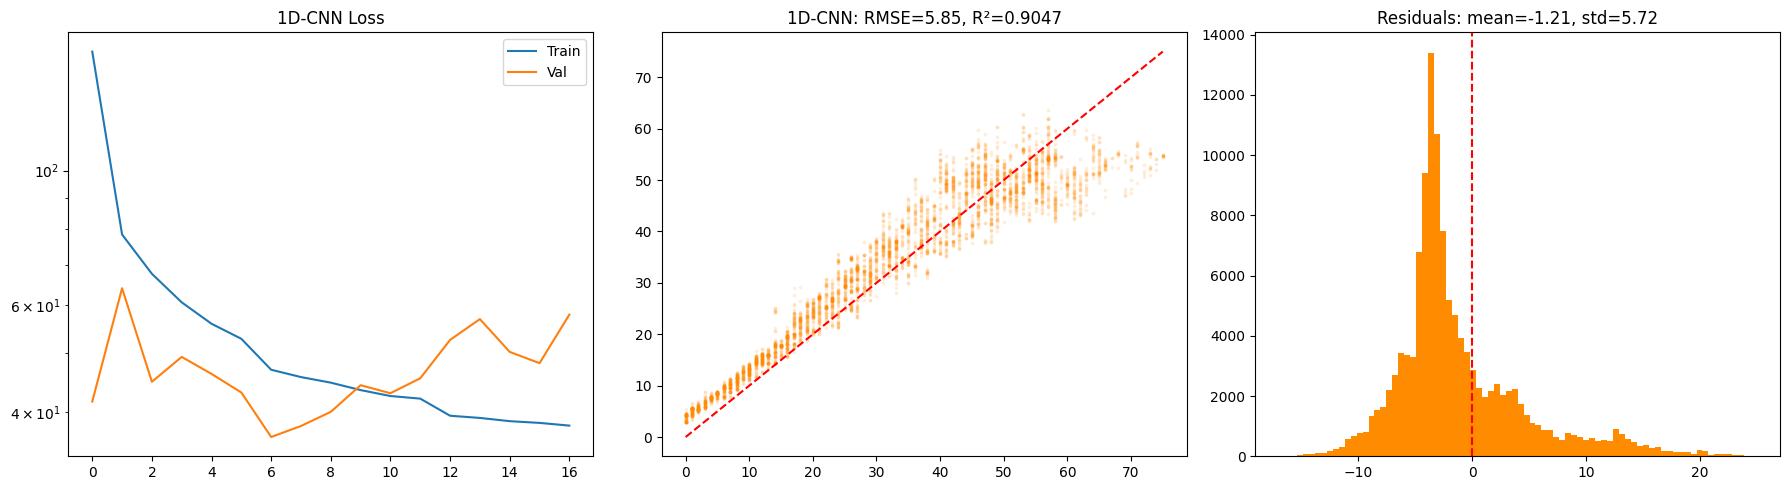

In [10]:
# 1D CNN

cnn = keras.Sequential([
    layers.Input(shape=(WINDOW, n_features)),
    
    # BLOCK 1
    layers.Conv1D(64, 5, activation='relu', padding='same'), # 64 filters, 5 timesteps wide
    layers.BatchNormalization(), # Normalises inputs
    layers.MaxPooling1D(2), # Halves time dimension (50 to 25)
    layers.Dropout(0.2), # Randomly switches off 20% of neurons during each training step
    
    # BLOCK 2
    layers.Conv1D(128, 3, activation='relu', padding='same'), # 128 filters, 3 timesteps wide
    layers.BatchNormalization(), 
    layers.MaxPooling1D(2),   # 25 to 12 
    layers.Dropout(0.2),
    
    # BLOCK 3
    layers.Conv1D(64, 3, activation='relu', padding='same'), # 46 filterss, 3 timesteps wide
    layers.BatchNormalization(), 
    layers.GlobalAveragePooling1D(), # Averages across all 12 remaining timesteps
    layers.Dropout(0.3), # Higher dropout rate before Dense layers (most prone to overfitting)

    # REGRESSION HEAD
    layers.Dense(64, activation='relu'),  # Fully connected with 64 neurons
    layers.Dropout(0.2),                      
    layers.Dense(32, activation='relu'),   # 32 neurons
    layers.Dense(1, activation='linear')   # Output layer: predicted RUL
])

cnn.compile(
    optimizer=optimizers.Adam(1e-3),   # Adam optimiser with learning rate 0.001
    loss='mse', 
    metrics=['mae'])
cnn.summary()

t0 = time.time()
h_cnn = cnn.fit(X_tr_w, y_tr_w,    # training data
                validation_data=(X_va_w, y_va_w),  #validation data
                epochs=50,  # maximum train 
                batch_size=256,   # 256 windows at the same time before updating weights
                
                callbacks=[callbacks.EarlyStopping('val_loss', patience=10, restore_best_weights=True),
                           
                callbacks.ReduceLROnPlateau('val_loss', factor=0.5, patience=5)],
                
                verbose=1)
cnn_time = time.time() - t0    #total training time

y_pred_cnn = cnn.predict(X_te_w, batch_size=256).ravel()    # predict RUL for all test windows
cnn_rmse = np.sqrt(mean_squared_error(y_te_w, y_pred_cnn))   # RMSE
cnn_mae  = mean_absolute_error(y_te_w, y_pred_cnn)     # MAE
cnn_r2   = r2_score(y_te_w, y_pred_cnn)     #R squared

print(f"\n1D-CNN: RMSE={cnn_rmse:.2f}, MAE={cnn_mae:.2f}, R²={cnn_r2:.4f}")
print(f"Params={cnn.count_params():,}, Time={cnn_time:.0f}s, Epochs={len(h_cnn.history['loss'])}")
print(f"vs XGBoost: {(1-cnn_rmse/xgb_rmse)*100:+.1f}%")    # Percentage improvement over XGBoost

# 3 panel figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(h_cnn.history['loss'], label='Train'); axes[0].plot(h_cnn.history['val_loss'], label='Val')
axes[0].legend(); axes[0].set_yscale('log'); axes[0].set_title('1D-CNN Loss')
s = np.random.choice(len(y_te_w), min(5000, len(y_te_w)), replace=False)
axes[1].scatter(y_te_w[s], y_pred_cnn[s], alpha=0.1, s=3, c='darkorange')
axes[1].plot([y_te_w.min(),y_te_w.max()],[y_te_w.min(),y_te_w.max()],'r--')
axes[1].set_title(f'1D-CNN: RMSE={cnn_rmse:.2f}, R²={cnn_r2:.4f}')
r = y_te_w - y_pred_cnn
axes[2].hist(r, bins=80, color='darkorange'); axes[2].axvline(0, color='red', ls='--')
axes[2].set_title(f'Residuals: mean={r.mean():.2f}, std={r.std():.2f}')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/cnn_results.png')
plt.show()

In [ ]:
# CNN-LSTM 

cl = keras.Sequential([
    layers.Input(shape=(WINDOW, n_features)),
    
    # BLOCK 1 - CN
    layers.Conv1D(64, 5, activation='relu', padding='same'),
    layers.BatchNormalization(), 
    layers.MaxPooling1D(2), 
    layers.Dropout(0.2),
    
    # BLOCK 2 - CN
    layers.Conv1D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(), 
    layers.MaxPooling1D(2), 
    layers.Dropout(0.2),
    
    # BLOCK 3 - LSTM
    layers.LSTM(64, return_sequences=True), 
    layers.Dropout(0.2),
    layers.LSTM(32, return_sequences=False), 
    layers.Dropout(0.2),
    
    # REGRESSION HEAD
    layers.Dense(32, activation='relu'), l
    ayers.Dropout(0.2),
    layers.Dense(1, activation='linear') # RUL prediction
])
cl.compile(
    optimizer=optimizers.Adam(1e-3), 
    loss='mse', 
    metrics=['mae'])
cl.summary()

t0 = time.time()
h_cl = cl.fit(
    X_tr_w, y_tr_w,        # training windows
    validation_data=(X_va_w, y_va_w),    # validation engine windows
    epochs=50,              # max 50 epochs
    batch_size=256,         # 256 windows per batch
              
                    callbacks=[callbacks.EarlyStopping('val_loss', patience=10, restore_best_weights=True),
                    
                    callbacks.ReduceLROnPlateau('val_loss', factor=0.5, patience=5)],
              
    verbose=1)
cl_time = time.time() - t0

y_pred_cl = cl.predict(X_te_w, batch_size=256).ravel()    # predict on test windows
cl_rmse = np.sqrt(mean_squared_error(y_te_w, y_pred_cl))
cl_mae  = mean_absolute_error(y_te_w, y_pred_cl)
cl_r2   = r2_score(y_te_w, y_pred_cl)

print(f"\nCNN-LSTM: RMSE={cl_rmse:.2f}, MAE={cl_mae:.2f}, R²={cl_r2:.4f}")
print(f"Params={cl.count_params():,}, Time={cl_time:.0f}s, Epochs={len(h_cl.history['loss'])}")
print(f"vs XGBoost: {(1-cl_rmse/xgb_rmse)*100:+.1f}%")    # Improvement over XGBoost
print(f"vs CNN:     {(1-cl_rmse/cnn_rmse)*100:+.1f}%")    # Improvement vs Standalone CNN

# 3 panel figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(h_cl.history['loss'], label='Train'); axes[0].plot(h_cl.history['val_loss'], label='Val')
axes[0].legend(); axes[0].set_yscale('log'); axes[0].set_title('CNN-LSTM Loss')
s = np.random.choice(len(y_te_w), min(5000, len(y_te_w)), replace=False)
axes[1].scatter(y_te_w[s], y_pred_cl[s], alpha=0.1, s=3, c='forestgreen')
axes[1].plot([y_te_w.min(),y_te_w.max()],[y_te_w.min(),y_te_w.max()],'r--')
axes[1].set_title(f'CNN-LSTM: RMSE={cl_rmse:.2f}, R²={cl_r2:.4f}')
r2 = y_te_w - y_pred_cl
axes[2].hist(r2, bins=80, color='forestgreen'); axes[2].axvline(0, color='red', ls='--')
axes[2].set_title(f'Residuals: mean={r2.mean():.2f}, std={r2.std():.2f}')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/cnn_lstm_results.png')
plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 50, 64)         │         5,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 12, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,209 (368.00 KB)

 Trainable params: 93,825 (366.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 122s 99ms/step - loss: 544.9155 - mae: 15.5814 - val_loss: 82.7739 - val_mae: 5.9685 - learning_rate: 0.0010
Epoch 2/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 115s 98ms/step - loss: 93.4784 - mae: 6.7484 - val_loss: 31.2760 - val_mae: 3.9612 - learning_rate: 0.0010
Epoch 3/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 118s 101ms/step - loss: 82.6576 - mae: 6.3271 - val_loss: 39.7730 - val_mae: 4.2301 - learning_rate: 0.0010
Epoch 4/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 123s 105ms/step - loss: 77.4470 - mae: 6.0883 - val_loss: 30.0452 - val_mae: 3.5801 - learning_rate: 0.0010
Epoch 5/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 119s 102ms/step - loss: 74.8107 - mae: 5.9648 - val_loss: 26.7497 - val_mae: 3.4726 - learning_rate: 0.0010
Epoch 6/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 104s 88ms/step - loss: 71.3937 - mae: 5.8182 - val_loss: 26.9309 - val_mae: 3.6728 - learning_rate: 0.0010
Epoch 7/50
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 103s 88ms/step - loss: 68.5541 - mae: 5.6920 - val_loss: 27

In [ ]:
# Model Comparison Summary

print("\n MODEL COMPARISON ")
print(f"{'Model':<20} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'Time':>10}")
print("-" * 58)
for name, rmse, mae, r2, t in [
    ('Linear Regression', lr_rmse, lr_mae, lr_r2, lr_time),
    ('XGBoost', xgb_rmse, xgb_mae, xgb_r2, xgb_time),
    ('1D-CNN', cnn_rmse, cnn_mae, cnn_r2, cnn_time),
    ('CNN-LSTM', cl_rmse, cl_mae, cl_r2, cl_time)]:
    print(f"{name:<20} {rmse:>8.2f} {mae:>8.2f} {r2:>8.4f} {t:>9.1f}s")

# Three-panel bar chart: RMSE, R squared, and training time

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names = ['LR', 'XGB', 'CNN', 'CNN-LSTM']
c = ['grey', 'steelblue', 'darkorange', 'forestgreen']
rmses = [lr_rmse, xgb_rmse, cnn_rmse, cl_rmse]

axes[0].bar(names, rmses, color=c); axes[0].set_ylabel('RMSE'); axes[0].set_title('RMSE')
for i,v in enumerate(rmses): axes[0].text(i, v+0.3, f'{v:.2f}', ha='center', fontsize=9)
axes[1].bar(names, [lr_r2, xgb_r2, cnn_r2, cl_r2], color=c); axes[1].set_ylabel('R²'); axes[1].set_title('R²')
axes[2].bar(names, [lr_time, xgb_time, cnn_time, cl_time], color=c)
axes[2].set_ylabel('Seconds'); axes[2].set_title('Train Time'); axes[2].set_yscale('log')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/comparison.png')
plt.show()

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)

# Subsample 3000 test points for SHAP
idx = np.random.choice(len(X_test_scaled), min(3000, len(X_test_scaled)), replace=False)
sv = explainer.shap_values(X_test_scaled[idx])
# positive SHAP value = feature pushed prediction higher
# Negative SHAP value = feature pushed prediction lower

# Beeswarm plot
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_test_scaled[idx], feature_names=feature_names, show=False, max_display=17)
plt.savefig('/kaggle/working/figures/shap_summary.png', bbox_inches='tight')
plt.show()

# Bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test_scaled[idx], feature_names=feature_names, plot_type='bar', show=False)
plt.savefig('/kaggle/working/figures/shap_bar.png', bbox_inches='tight')
plt.show()

# Calulating and printing importance
ms = np.abs(sv).mean(0); total = ms.sum()
print("SHAP importance:")
for i in np.argsort(ms)[::-1][:10]:
    print(f"  {feature_names[i]:>8s}: {ms[i]:.4f} ({ms[i]/total*100:.1f}%)")

sensor_pct = sum(ms[i] for i,c in enumerate(feature_names) if c in sensor_names) / total * 100
op_pct = 100 - sensor_pct
print(f"\nSensors: {sensor_pct:.1f}% | Operating: {op_pct:.1f}%")

# Temperature sensors specifically
temp_names = ['T2', 'T24', 'T30', 'T48', 'T50']
temp_pct = sum(ms[i] for i, c in enumerate(feature_names) if c in temp_names) / total * 100
print(f"Temperature sensors only: {temp_pct:.1f}%")

In [ ]:
# Error analysis

print("\nError by RUL range (XGBoost):")
res = y_test_raw - y_pred_xgb
rul_max = y_test_raw.max()
for label, lo, hi in [('End-of-life (0-10)', 0, 10), ('Mid-life (10-40)', 10, 40), ('Early (40+)', 40, rul_max+1)]:
    mask = (y_test_raw >= lo) & (y_test_raw < hi)
    if mask.sum() > 0:
        rmse = np.sqrt(mean_squared_error(y_test_raw[mask], y_pred_xgb[mask]))
        print(f"  {label}: RMSE={rmse:.2f} (n={mask.sum():,})")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs True RUL
s = np.random.choice(len(res), min(5000, len(res)), replace=False
axes[0].scatter(y_test_raw[s], res[s], alpha=0.1, s=3)
axes[0].axhline(0, color='red', ls='--'); 
axes[0].set_xlabel('True RUL'); axes[0].set_ylabel('Residual')

# Residual histogram
axes[1].hist(res[s], bins=80); 
axes[1].axvline(0, color='red', ls='--')
axes[1].set_title(f'mean={res.mean():.2f}, std={res.std():.2f}')


plt.tight_layout()
plt.savefig('/kaggle/working/figures/error_analysis.png')
plt.show()

In [ ]:
# Save and print numbers for report

cnn.save('/kaggle/working/cnn_model.keras')
cl.save('/kaggle/working/cnn_lstm_model.keras')
xgb_model.save_model('/kaggle/working/xgb_model.json')

print("\n NUMBERS FOR REPORT\n")
print(f"Dataset: N-CMAPSS DS02, {len(y_train_raw)+len(y_test_raw):,} total samples, 1Hz")
print(f"Train: {len(y_train_raw):,} samples, engines {sorted(np.unique(unit_train))}")
print(f"Test:  {len(y_test_raw):,} samples, engines {sorted(np.unique(unit_test))}")
print(f"Features: {n_features} ({len(op_names)} operating + {len(sensor_names)} sensors)")
print(f"\nLinear Regression: RMSE={lr_rmse:.2f}, MAE={lr_mae:.2f}, R²={lr_r2:.4f}")
print(f"XGBoost:           RMSE={xgb_rmse:.2f}, MAE={xgb_mae:.2f}, R²={xgb_r2:.4f}")
print(f"  Best config: depth={int(best['depth'])}, lr={best['lr']}")
print(f"  5-Fold CV:   {np.mean(cv):.2f} ± {np.std(cv):.2f}")
print(f"1D-CNN:            RMSE={cnn_rmse:.2f}, MAE={cnn_mae:.2f}, R²={cnn_r2:.4f}, params={cnn.count_params():,}")
print(f"CNN-LSTM:          RMSE={cl_rmse:.2f}, MAE={cl_mae:.2f}, R²={cl_r2:.4f}, params={cl.count_params():,}")
print(f"\nXGBoost vs LR:      {(1-xgb_rmse/lr_rmse)*100:+.1f}%")
print(f"1D-CNN vs XGBoost:  {(1-cnn_rmse/xgb_rmse)*100:+.1f}%")
print(f"CNN-LSTM vs XGBoost:{(1-cl_rmse/xgb_rmse)*100:+.1f}%")

print(f"\nFigures saved:")
for f in sorted(os.listdir('/kaggle/working/figures/')): print(f"  {f}")
print("\nDone.")

In [ ]:
# Fair windowed comparison: XGBoost on same test data as DL models
xgb_win_preds = xgb_model.predict(X_te_w[:, -1, :])
xgb_win_rmse = np.sqrt(mean_squared_error(y_te_w, xgb_win_preds))
print(f"XGBoost on windowed test: RMSE={xgb_win_rmse:.2f}")
print(f"CNN still better: {(1-cnn_rmse/xgb_win_rmse)*100:+.1f}%")